In [1]:
import pandas as pd
import numpy as np

import torch
import torch.utils._pytree as _torch_pytree

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tabm import TabM

# Compatibility patch for packages expecting newer torch pytree API
if not hasattr(_torch_pytree, "register_pytree_node") and hasattr(_torch_pytree, "_register_pytree_node"):
    def _compat_register_pytree_node(cls, flatten_fn, unflatten_fn, *args, **kwargs):
        return _torch_pytree._register_pytree_node(cls, flatten_fn, unflatten_fn)
    _torch_pytree.register_pytree_node = _compat_register_pytree_node

In [2]:
# Load data
train_path = "data/train.csv"
test_path = "data/test.csv"
sample_sub_path = "data/sample_submission.csv"

In [3]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

In [4]:
target_col = "diagnosed_diabetes"
id_col = "id"

In [5]:
# Split features and target
X = train_df.drop(columns=[target_col]).copy()
y = train_df[target_col].copy()
X_test = test_df.copy()

In [6]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [col for col in num_cols if col in X.columns]
cat_cols = [col for col in cat_cols if col in X.columns]

X = X[num_cols + cat_cols].copy()
X_test = X_test[num_cols + cat_cols].copy()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

Numeric columns: ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
X shape: (700000, 25)
X_test shape: (300000, 25)


In [7]:
# TabM preprocessing (separate from one-hot pipeline)
tabm_num_imputer = SimpleImputer(strategy="median")
tabm_scaler = StandardScaler()
tabm_cat_imputer = SimpleImputer(strategy="most_frequent")

X_num_tabm = pd.DataFrame(tabm_num_imputer.fit_transform(X[num_cols]), columns=num_cols)
X_num_tabm = pd.DataFrame(tabm_scaler.fit_transform(X_num_tabm), columns=num_cols)
X_test_num_tabm = pd.DataFrame(tabm_num_imputer.transform(X_test[num_cols]), columns=num_cols)
X_test_num_tabm = pd.DataFrame(tabm_scaler.transform(X_test_num_tabm), columns=num_cols)

if len(cat_cols) > 0:
    X_cat_raw_tabm = pd.DataFrame(tabm_cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols).astype(str)
    X_test_cat_raw_tabm = pd.DataFrame(tabm_cat_imputer.transform(X_test[cat_cols]), columns=cat_cols).astype(str)

    X_all_cat_tabm = pd.concat([X_cat_raw_tabm, X_test_cat_raw_tabm], axis=0, ignore_index=True)
    tabm_cat_cardinalities = []
    tabm_encoded_cols = []

    for col in cat_cols:
        codes, uniques = pd.factorize(X_all_cat_tabm[col], sort=True)
        tabm_encoded_cols.append(codes)
        tabm_cat_cardinalities.append(len(uniques))

    X_all_cat_enc_tabm = np.vstack(tabm_encoded_cols).T.astype(np.int64)
    X_cat_tabm = X_all_cat_enc_tabm[: len(X)]
    X_test_cat_tabm = X_all_cat_enc_tabm[len(X):]
else:
    tabm_cat_cardinalities = []
    X_cat_tabm = np.zeros((len(X), 0), dtype=np.int64)
    X_test_cat_tabm = np.zeros((len(X_test), 0), dtype=np.int64)

X_num_np_tabm = X_num_tabm.to_numpy(dtype=np.float32)
X_test_num_np_tabm = X_test_num_tabm.to_numpy(dtype=np.float32)
y_np_tabm = y.to_numpy(dtype=np.float32)

print("TabM numeric shape:", X_num_np_tabm.shape)
print("TabM categorical shape:", X_cat_tabm.shape)
print("TabM cat cardinalities:", len(tabm_cat_cardinalities))

TabM numeric shape: (700000, 19)
TabM categorical shape: (700000, 6)
TabM cat cardinalities: 6


In [8]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    verbose_feature_names_out=False
)

In [9]:
# LightGBM pipeline
lgbm_model = LGBMClassifier(
    verbosity=-1,
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1
)

lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

# Hyperparameter search space
param_dist = {
    "model__num_leaves": [31, 50, 64, 80],
    "model__max_depth": [-1, 5, 6, 7],
    "model__learning_rate": [0.03, 0.05, 0.07],
    "model__n_estimators": [300, 500, 700],
    "model__min_child_samples": [20, 40, 60],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__reg_alpha": [0.0, 0.5, 1.0],
    "model__reg_lambda": [0.0, 0.5, 1.0]
}

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist,
    n_iter=12,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

# Run search
random_search.fit(X, y)

print("Best CV score:", random_search.best_score_)
print("Best params:")

for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

Best CV score: 0.7256695733960665
Best params:
  model__subsample: 0.9
  model__reg_lambda: 0.5
  model__reg_alpha: 1.0
  model__num_leaves: 80
  model__n_estimators: 500
  model__min_child_samples: 60
  model__max_depth: -1
  model__learning_rate: 0.03
  model__colsample_bytree: 0.7


In [11]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

xgb_param_dist = {
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.07],
    "model__n_estimators": [300, 500, 700],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__reg_alpha": [0.0, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X, y)

print("XGBoost Best CV score:", xgb_search.best_score_)
print("XGBoost Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
XGBoost Best CV score: 0.7261790067494214
XGBoost Best params:
  model__subsample: 0.8
  model__reg_lambda: 2.0
  model__reg_alpha: 0.5
  model__n_estimators: 700
  model__min_child_weight: 5
  model__max_depth: 5
  model__learning_rate: 0.07
  model__colsample_bytree: 0.8


In [12]:
cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

cat_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", cat_model)
])

cat_param_dist = {
    "model__depth": [4, 5, 6, 7],
    "model__learning_rate": [0.03, 0.05, 0.07],
    "model__iterations": [300, 500, 700],
    "model__l2_leaf_reg": [1, 3, 5, 7, 9],
    "model__subsample": [0.7, 0.8, 0.9]
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

cat_search.fit(X, y)

print("CatBoost Best CV score:", cat_search.best_score_)
print("CatBoost Best params:")
for k, v in cat_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost Best CV score: 0.725627781433548
CatBoost Best params:
  model__subsample: 0.9
  model__learning_rate: 0.07
  model__l2_leaf_reg: 5
  model__iterations: 700
  model__depth: 7


In [13]:
# TabM model (using tuned hyperparameters from tabm.ipynb)
tabm_device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("TabM device:", tabm_device)

tabm_params = {
    "k": 16,
    "n_blocks": 3,
    "d_block": 128,
    "dropout": 0.1,
    "arch_type": "tabm",
}

tabm_model = TabM.make(
    n_num_features=X_num_np_tabm.shape[1],
    cat_cardinalities=tabm_cat_cardinalities,
    d_out=1,
    **tabm_params,
).to(tabm_device)

tabm_optimizer = torch.optim.AdamW(tabm_model.parameters(), lr=2e-3, weight_decay=3e-4)
tabm_criterion = torch.nn.BCEWithLogitsLoss()

train_ds_tabm = TensorDataset(
    torch.tensor(X_num_np_tabm, dtype=torch.float32),
    torch.tensor(X_cat_tabm, dtype=torch.long),
    torch.tensor(y_np_tabm, dtype=torch.float32),
)
train_dl_tabm = DataLoader(train_ds_tabm, batch_size=1024, shuffle=False)

epochs_tabm = 40
for epoch in range(1, epochs_tabm + 1):
    tabm_model.train()
    running_loss = 0.0

    for xb_num, xb_cat, yb in train_dl_tabm:
        xb_num = xb_num.to(tabm_device)
        xb_cat = xb_cat.to(tabm_device)
        yb = yb.to(tabm_device)

        tabm_optimizer.zero_grad()
        logits = tabm_model(xb_num, xb_cat).squeeze(-1)  # (B, k)
        yb_expanded = yb.unsqueeze(1).expand(-1, logits.shape[1])
        loss = tabm_criterion(logits, yb_expanded)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tabm_model.parameters(), 1.0)
        tabm_optimizer.step()

        running_loss += loss.item() * len(yb)

    print(f"TabM Full-train epoch {epoch:03d} | loss={running_loss / len(train_ds_tabm):.5f}")

# Predict on test for blending
tabm_model.eval()
tabm_probs = []

test_ds_tabm = TensorDataset(
    torch.tensor(X_test_num_np_tabm, dtype=torch.float32),
    torch.tensor(X_test_cat_tabm, dtype=torch.long),
)
test_dl_tabm = DataLoader(test_ds_tabm, batch_size=4096, shuffle=False)

with torch.no_grad():
    for xb_num, xb_cat in test_dl_tabm:
        xb_num = xb_num.to(tabm_device)
        xb_cat = xb_cat.to(tabm_device)

        logits = tabm_model(xb_num, xb_cat).squeeze(-1)    # (B, k)
        probs = torch.sigmoid(logits).mean(dim=1)          # (B,)
        tabm_probs.extend(probs.cpu().numpy())

tabm_pred = np.asarray(tabm_probs, dtype=float)
print("TabM test prediction shape:", tabm_pred.shape)

TabM device: mps
TabM Full-train epoch 001 | loss=0.60681
TabM Full-train epoch 002 | loss=0.60373
TabM Full-train epoch 003 | loss=0.60329
TabM Full-train epoch 004 | loss=0.60301
TabM Full-train epoch 005 | loss=0.60279
TabM Full-train epoch 006 | loss=0.60262
TabM Full-train epoch 007 | loss=0.60250
TabM Full-train epoch 008 | loss=0.60236
TabM Full-train epoch 009 | loss=0.60222
TabM Full-train epoch 010 | loss=0.60213
TabM Full-train epoch 011 | loss=0.60205
TabM Full-train epoch 012 | loss=0.60196
TabM Full-train epoch 013 | loss=0.60189
TabM Full-train epoch 014 | loss=0.60181
TabM Full-train epoch 015 | loss=0.60175
TabM Full-train epoch 016 | loss=0.60170
TabM Full-train epoch 017 | loss=0.60163
TabM Full-train epoch 018 | loss=0.60158
TabM Full-train epoch 019 | loss=0.60155
TabM Full-train epoch 020 | loss=0.60148
TabM Full-train epoch 021 | loss=0.60146
TabM Full-train epoch 022 | loss=0.60143
TabM Full-train epoch 023 | loss=0.60139
TabM Full-train epoch 024 | loss=0.60132

In [14]:
# Best model
best_lgbm_pipeline = random_search.best_estimator_
best_xgb_pipeline = xgb_search.best_estimator_
best_cat_pipeline = cat_search.best_estimator_

# Predict test
lgb_pred = best_lgbm_pipeline.predict_proba(X_test)[:, 1]
xgb_pred = best_xgb_pipeline.predict_proba(X_test)[:, 1]
cat_pred = best_cat_pipeline.predict_proba(X_test)[:, 1]

/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
# OOF-based blend weight tuning (AUC-optimized)
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF containers
lgb_oof = np.zeros(len(X), dtype=float)
xgb_oof = np.zeros(len(X), dtype=float)
cat_oof = np.zeros(len(X), dtype=float)
tabm_oof = np.zeros(len(X), dtype=float)

# --- sklearn pipelines OOF (LGB/XGB/CAT) ---
for fold, (tr_idx, val_idx) in enumerate(cv_oof.split(X, y), start=1):
    print(f"\n[OOF] Fold {fold}/5")

    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr = y.iloc[tr_idx]

    lgb_fold = clone(best_lgbm_pipeline)
    lgb_fold.fit(X_tr, y_tr)
    lgb_oof[val_idx] = lgb_fold.predict_proba(X_val)[:, 1]

    xgb_fold = clone(best_xgb_pipeline)
    xgb_fold.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

    cat_fold = clone(best_cat_pipeline)
    cat_fold.fit(X_tr, y_tr)
    cat_oof[val_idx] = cat_fold.predict_proba(X_val)[:, 1]

# --- TabM OOF ---
for fold, (tr_idx, val_idx) in enumerate(cv_oof.split(X_num_np_tabm, y_np_tabm), start=1):
    print(f"[OOF-TabM] Fold {fold}/5")

    fold_model = TabM.make(
        n_num_features=X_num_np_tabm.shape[1],
        cat_cardinalities=tabm_cat_cardinalities,
        d_out=1,
        **tabm_params,
    ).to(tabm_device)

    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=2e-3, weight_decay=3e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    tr_ds = TensorDataset(
        torch.tensor(X_num_np_tabm[tr_idx], dtype=torch.float32),
        torch.tensor(X_cat_tabm[tr_idx], dtype=torch.long),
        torch.tensor(y_np_tabm[tr_idx], dtype=torch.float32),
    )
    tr_dl = DataLoader(tr_ds, batch_size=1024, shuffle=False)

    best_auc = -np.inf
    best_state = None
    wait = 0
    max_epochs = 25
    patience = 5

    for epoch in range(1, max_epochs + 1):
        fold_model.train()
        for xb_num, xb_cat, yb in tr_dl:
            xb_num = xb_num.to(tabm_device)
            xb_cat = xb_cat.to(tabm_device)
            yb = yb.to(tabm_device)

            optimizer.zero_grad()
            logits = fold_model(xb_num, xb_cat).squeeze(-1)
            yb_expanded = yb.unsqueeze(1).expand(-1, logits.shape[1])
            loss = criterion(logits, yb_expanded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            optimizer.step()

        # fold validation AUC for early stopping
        fold_model.eval()
        val_probs = []
        val_ds = TensorDataset(
            torch.tensor(X_num_np_tabm[val_idx], dtype=torch.float32),
            torch.tensor(X_cat_tabm[val_idx], dtype=torch.long),
        )
        val_dl = DataLoader(val_ds, batch_size=4096, shuffle=False)
        with torch.no_grad():
            for xb_num, xb_cat in val_dl:
                xb_num = xb_num.to(tabm_device)
                xb_cat = xb_cat.to(tabm_device)
                logits = fold_model(xb_num, xb_cat).squeeze(-1)
                probs = torch.sigmoid(logits).mean(dim=1)
                val_probs.extend(probs.cpu().numpy())

        val_auc = roc_auc_score(y_np_tabm[val_idx], np.asarray(val_probs, dtype=float))
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in fold_model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    fold_model.load_state_dict(best_state)
    fold_model.eval()

    final_val_probs = []
    val_ds = TensorDataset(
        torch.tensor(X_num_np_tabm[val_idx], dtype=torch.float32),
        torch.tensor(X_cat_tabm[val_idx], dtype=torch.long),
    )
    val_dl = DataLoader(val_ds, batch_size=4096, shuffle=False)
    with torch.no_grad():
        for xb_num, xb_cat in val_dl:
            xb_num = xb_num.to(tabm_device)
            xb_cat = xb_cat.to(tabm_device)
            logits = fold_model(xb_num, xb_cat).squeeze(-1)
            probs = torch.sigmoid(logits).mean(dim=1)
            final_val_probs.extend(probs.cpu().numpy())

    tabm_oof[val_idx] = np.asarray(final_val_probs, dtype=float)

# Evaluate single-model OOF AUC
print("\nOOF AUC - LGB:", roc_auc_score(y, lgb_oof))
print("OOF AUC - XGB:", roc_auc_score(y, xgb_oof))
print("OOF AUC - CAT:", roc_auc_score(y, cat_oof))
print("OOF AUC - TabM:", roc_auc_score(y, tabm_oof))

# Weight optimization on OOF predictions
oof_stack = np.column_stack([lgb_oof, xgb_oof, cat_oof, tabm_oof])
best_auc = -1.0
best_w = None

rng = np.random.default_rng(42)
for _ in range(15000):
    w = rng.dirichlet(np.ones(oof_stack.shape[1]))
    blend_oof = oof_stack @ w
    auc = roc_auc_score(y, blend_oof)
    if auc > best_auc:
        best_auc = auc
        best_w = w

print("\nBest OOF blended AUC:", best_auc)
print("Best weights [LGB, XGB, CAT, TabM]:", best_w)

# Apply best weights to test predictions
best_blend_test = (
    best_w[0] * lgb_pred +
    best_w[1] * xgb_pred +
    best_w[2] * cat_pred +
    best_w[3] * tabm_pred
)

target_submission_col = sample_sub.columns[1]
submission_best_oof_blend = sample_sub.copy()
submission_best_oof_blend[target_submission_col] = best_blend_test.astype(float)
submission_best_oof_blend.to_csv("submissions/blend_best_oof_weighted_lgb_xgb_cat_tabm.csv", index=False)
print("Saved: submissions/blend_best_oof_weighted_lgb_xgb_cat_tabm.csv")


[OOF] Fold 1/5


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[OOF] Fold 2/5


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[OOF] Fold 3/5


...


[OOF] Fold 4/5


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[OOF] Fold 5/5


/opt/anaconda3/envs/dml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[OOF-TabM] Fold 1/5
[OOF-TabM] Fold 2/5
[OOF-TabM] Fold 3/5
[OOF-TabM] Fold 4/5
[OOF-TabM] Fold 5/5

OOF AUC - LGB: 0.7267241204952065
OOF AUC - XGB: 0.7261768900859205
OOF AUC - CAT: 0.7256230298835393
OOF AUC - TabM: 0.6959473250746515

Best OOF blended AUC: 0.727104977291301
Best weights [LGB, XGB, CAT, TabM]: [0.52066682 0.34286204 0.13529734 0.00117381]
Saved: submissions/blend_best_oof_weighted_lgb_xgb_cat_tabm.csv


In [ ]:
# Find the best OOF blend weights for LGB, XGB, and CAT only
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

required_vars = ["lgb_oof", "xgb_oof", "cat_oof", "y", "lgb_pred", "xgb_pred", "cat_pred", "sample_sub"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Run the OOF generation and prediction cells first.")

blend_oof_stack = np.column_stack([lgb_oof, xgb_oof, cat_oof])
y_arr = y.to_numpy()

# Baseline fixed weights
baseline_w = np.array([0.70, 0.15, 0.15])
baseline_auc = roc_auc_score(y_arr, blend_oof_stack @ baseline_w)
print(f"Baseline blend AUC [0.70,0.15,0.15]: {baseline_auc:.6f}")

# Use a sample to search weight space more efficiently
rng = np.random.default_rng(42)
sample_size = min(120000, len(y_arr))
sample_idx = rng.choice(len(y_arr), size=sample_size, replace=False)
blend_oof_sample = blend_oof_stack[sample_idx]
y_sample = y_arr[sample_idx]

best_auc = baseline_auc
best_w = baseline_w

candidate_weights = []
for lgb_w in np.linspace(0.55, 0.90, 36):
    for xgb_w in np.linspace(0.0, 0.45, 46):
        cat_w = 1.0 - lgb_w - xgb_w
        if cat_w < 0 or cat_w > 0.50:
            continue
        candidate_weights.append([lgb_w, xgb_w, cat_w])

candidate_weights = np.array(candidate_weights)
print(f"Evaluating {len(candidate_weights)} weight candidates on a {sample_size}-row sample...")

sample_auc = []
for w in candidate_weights:
    blend_oof = blend_oof_sample @ w
    sample_auc.append(roc_auc_score(y_sample, blend_oof))

top_indices = np.argsort(sample_auc)[-20:][::-1]
print("Top 3 candidate weights on sample:")
for rank, idx in enumerate(top_indices[:3], start=1):
    print(f"{rank}. weight={candidate_weights[idx]}, sample AUC={sample_auc[idx]:.6f}")

print("Evaluating top candidates on full OOF...")
for idx in top_indices:
    w = candidate_weights[idx]
    auc = roc_auc_score(y_arr, blend_oof_stack @ w)
    if auc > best_auc:
        best_auc = auc
        best_w = w

# Try a simple logistic regression meta-model as a comparison
lr = LogisticRegression(max_iter=2000, solver="lbfgs")
lr.fit(blend_oof_stack, y_arr)
lr_oof = lr.predict_proba(blend_oof_stack)[:, 1]
lr_auc = roc_auc_score(y_arr, lr_oof)
print(f"LogisticRegression meta AUC: {lr_auc:.6f}")

if lr_auc > best_auc:
    print("Using logistic regression meta-model because it beats the best convex blend.")
    blend_test = lr.predict_proba(np.column_stack([lgb_pred, xgb_pred, cat_pred]))[:, 1]
    submission = sample_sub.copy()
    submission[target_col] = blend_test.astype(float)
    submission.to_csv("submissions/blend_best_oof_weighted_lgb_xgb_cat_lr.csv", index=False)
    print("Saved: submissions/blend_best_oof_weighted_lgb_xgb_cat_lr.csv")
else:
    print(f"Best full OOF blended AUC (LGB/XGB/CAT): {best_auc:.6f}")
    print("Best weights [LGB, XGB, CAT]:", best_w)
    blend_test = (
        best_w[0] * lgb_pred +
        best_w[1] * xgb_pred +
        best_w[2] * cat_pred
    )
    submission = sample_sub.copy()
    submission[target_col] = blend_test.astype(float)
    submission.to_csv("submissions/blend_best_oof_weighted_lgb_xgb_cat.csv", index=False)
    print("Saved: submissions/blend_best_oof_weighted_lgb_xgb_cat.csv")

Baseline blend AUC [0.70,0.15,0.15]: 0.727024
Evaluating 996 weight candidates on a 120000-row sample...


In [18]:
# Fast OOF blend weight search (rerunnable, does not retrain models)
import numpy as np
from sklearn.metrics import roc_auc_score

# Check OOF arrays and y
required_vars = ["lgb_oof", "xgb_oof", "cat_oof", "tabm_oof", "y"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Run the OOF cell first.")

# Stack OOF predictions
_oof_stack = np.column_stack([lgb_oof, xgb_oof, cat_oof, tabm_oof])
_best_auc = -1.0
_best_w = None

# Use a smaller number of candidates for 700k rows.
# Each roc_auc_score call sorts 700k values, so 15k iterations is very expensive.
n_candidates = 500
_rng = np.random.default_rng(42)
for i in range(n_candidates):
    w = _rng.dirichlet(np.ones(_oof_stack.shape[1]))
    blend_oof = _oof_stack @ w
    auc = roc_auc_score(y, blend_oof)
    if auc > _best_auc:
        _best_auc = auc
        _best_w = w

print(f"\n[FAST SEARCH] Best OOF blended AUC after {n_candidates} candidates: {_best_auc}")
print("[FAST SEARCH] Best weights [LGB, XGB, CAT, TabM]:", _best_w)

# Optionally, assign to global best_w/best_auc if you want to use them elsewhere
best_w = _best_w
best_auc = _best_auc


[FAST SEARCH] Best OOF blended AUC after 500 candidates: 0.7271028557644637
[FAST SEARCH] Best weights [LGB, XGB, CAT, TabM]: [0.63162499 0.35404746 0.01287533 0.00145223]


In [22]:
# Save individual submissions

target_submission_col = sample_sub.columns[1]

submission_lgb = sample_sub.copy()
submission_lgb[target_submission_col] = lgb_pred.astype(float)
submission_lgb.to_csv("submissions/lightgbm_with_id_random_search.csv", index=False)

submission_xgb = sample_sub.copy()
submission_xgb[target_submission_col] = xgb_pred.astype(float)
submission_xgb.to_csv("submissions/xgboost_with_id_random_search.csv", index=False)

submission_cat = sample_sub.copy()
submission_cat[target_submission_col] = cat_pred.astype(float)
submission_cat.to_csv("submissions/catboost_with_id_random_search.csv", index=False)

submission_tabm = sample_sub.copy()
submission_tabm[target_submission_col] = tabm_pred.astype(float)
submission_tabm.to_csv("submissions/tabm_with_id_tuned.csv", index=False)

print("Saved individual submissions (LightGBM/XGBoost/CatBoost/TabM).")

Saved individual submissions (LightGBM/XGBoost/CatBoost/TabM).


In [23]:
lgb_path = "submissions/lightgbm_with_id_random_search.csv"
xgb_path = "submissions/xgboost_with_id_random_search.csv"
cat_path = "submissions/catboost_with_id_random_search.csv"
tabm_path = "submissions/tabm_with_id_tuned.csv"

lgb_sub = pd.read_csv(lgb_path)
xgb_sub = pd.read_csv(xgb_path)
cat_sub = pd.read_csv(cat_path)
tabm_sub = pd.read_csv(tabm_path)

In [ ]:
target_col = lgb_sub.columns[1]

# 2-model blends
blend_lgb_xgb_70_30 = lgb_sub.copy()
blend_lgb_xgb_70_30[target_col] = (
    0.70 * lgb_sub[target_col] +
    0.30 * xgb_sub[target_col]
)
blend_lgb_xgb_70_30.to_csv("submissions/blend_lgb_xgb_70_30.csv", index=False)

blend_lgb_tabm_70_30 = lgb_sub.copy()
blend_lgb_tabm_70_30[target_col] = (
    0.70 * lgb_sub[target_col] +
    0.30 * tabm_sub[target_col]
)
blend_lgb_tabm_70_30.to_csv("submissions/blend_lgb_tabm_70_30.csv", index=False)

In [ ]:
blend_lgb_xgb_60_40 = lgb_sub.copy()
blend_lgb_xgb_60_40[target_col] = (
    0.60 * lgb_sub[target_col] +
    0.40 * xgb_sub[target_col]
)
blend_lgb_xgb_60_40.to_csv("submissions/blend_lgb_xgb_60_40.csv", index=False)

In [ ]:
# 3-model blends
blend_lgb_xgb_cat_65_25_10 = lgb_sub.copy()
blend_lgb_xgb_cat_65_25_10[target_col] = (
    0.65 * lgb_sub[target_col] +
    0.25 * xgb_sub[target_col] +
    0.10 * cat_sub[target_col]
)
blend_lgb_xgb_cat_65_25_10.to_csv("submissions/blend_lgb_xgb_cat_65_25_10.csv", index=False)

blend_lgb_xgb_tabm_60_20_20 = lgb_sub.copy()
blend_lgb_xgb_tabm_60_20_20[target_col] = (
    0.60 * lgb_sub[target_col] +
    0.20 * xgb_sub[target_col] +
    0.20 * tabm_sub[target_col]
)
blend_lgb_xgb_tabm_60_20_20.to_csv("submissions/blend_lgb_xgb_tabm_60_20_20.csv", index=False)

In [ ]:
blend_lgb_xgb_cat_60_25_15 = lgb_sub.copy()
blend_lgb_xgb_cat_60_25_15[target_col] = (
    0.60 * lgb_sub[target_col] +
    0.25 * xgb_sub[target_col] +
    0.15 * cat_sub[target_col]
)
blend_lgb_xgb_cat_60_25_15.to_csv("submissions/blend_lgb_xgb_cat_60_25_15.csv", index=False)

In [ ]:
blend_lgb_xgb_cat_70_15_15 = lgb_sub.copy()
blend_lgb_xgb_cat_70_15_15[target_col] = (
    0.70 * lgb_sub[target_col] +
    0.15 * xgb_sub[target_col] +
    0.15 * cat_sub[target_col]
)
blend_lgb_xgb_cat_70_15_15.to_csv("submissions/blend_lgb_xgb_cat_70_15_15.csv", index=False)

# 4-model blend (adding TabM)
blend_lgb_xgb_cat_tabm_Best = lgb_sub.copy()
blend_lgb_xgb_cat_tabm_Best[target_col] = (
    0.631625 * lgb_sub[target_col] +
    0.354047 * xgb_sub[target_col] +
    0.012875 * cat_sub[target_col] +
    0.001452 * tabm_sub[target_col]
)
blend_lgb_xgb_cat_tabm_Best.to_csv("submissions/blend_lgb_xgb_cat_tabm_Best.csv", index=False)

print("Saved Best blend submissions including TabM.")

Saved Best blend submissions including TabM.


In [29]:
from sklearn.isotonic import IsotonicRegression

print("Training calibrated blend_lgb_xgb_cat_tabm_Best (Isotonic)...")

# Use the best fixed weights for the blend, then calibrate that single blended score.
if not all(name in globals() for name in ["lgb_oof", "xgb_oof", "cat_oof", "tabm_oof", "y"]):
    raise RuntimeError("Missing OOF predictions or target y. Run the OOF cell first.")

blend_oof = (
    0.52066682 * lgb_oof +
    0.34286204 * xgb_oof +
    0.13529734 * cat_oof +
    0.00117381 * tabm_oof
)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(blend_oof, y)

blend_test = (
    0.52066682 * lgb_pred +
    0.34286204 * xgb_pred +
    0.13529734 * cat_pred +
    0.00117381 * tabm_pred
)
calibrated_blend_test = iso.predict(blend_test)

submission_calibrated = sample_sub.copy()
submission_calibrated[target_col] = calibrated_blend_test.astype(float)
submission_calibrated.to_csv("submissions/blend_lgb_xgb_cat_tabm_Best_calibrated.csv", index=False)

print("Saved calibrated blend submission:", "submissions/blend_lgb_xgb_cat_tabm_Best_calibrated.csv")

Training calibrated blend_lgb_xgb_cat_tabm_Best (Isotonic)...
Saved calibrated blend submission: submissions/blend_lgb_xgb_cat_tabm_Best_calibrated.csv


Final learned blend weights (sorted):
      model    weight
0  LightGBM  0.631625
1   XGBoost  0.354047
2  CatBoost  0.012875
3      TabM  0.001452

OOF prediction correlation matrix:
           lgb_oof   xgb_oof   cat_oof  tabm_oof
lgb_oof   1.000000  0.988371  0.990197  0.899791
xgb_oof   0.988371  1.000000  0.988067  0.895272
cat_oof   0.990197  0.988067  1.000000  0.910096
tabm_oof  0.899791  0.895272  0.910096  1.000000


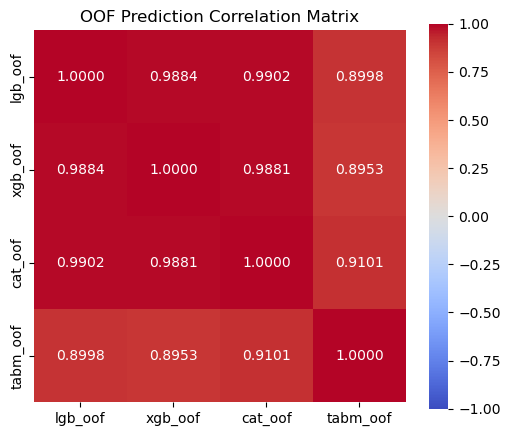

In [28]:
# Diagnostics: final learned weights + OOF prediction correlation matrix

if "best_w" not in globals():
    raise RuntimeError("best_w not found. Run the OOF-based blend weight tuning cell first.")

if not all(name in globals() for name in ["lgb_oof", "xgb_oof", "cat_oof", "tabm_oof"]):
    raise RuntimeError("OOF predictions not found. Run the OOF-based blend weight tuning cell first.")

weight_table = pd.DataFrame({
    "model": ["LightGBM", "XGBoost", "CatBoost", "TabM"],
    "weight": [float(best_w[0]), float(best_w[1]), float(best_w[2]), float(best_w[3])],
}).sort_values("weight", ascending=False).reset_index(drop=True)

print("Final learned blend weights (sorted):")
print(weight_table)

oof_pred_df = pd.DataFrame({
    "lgb_oof": lgb_oof,
    "xgb_oof": xgb_oof,
    "cat_oof": cat_oof,
    "tabm_oof": tabm_oof,
})

corr_mat = oof_pred_df.corr(method="pearson")
print("\nOOF prediction correlation matrix:")
print(corr_mat)

# Optional: quick visualization
try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_mat, annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
    plt.title("OOF Prediction Correlation Matrix")
    plt.show()
except Exception as e:
    print(f"\nHeatmap skipped: {e}")